In [ ]:
# xgboost model to predict chirality indices (n, m)
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import seaborn as sns
import xgboost as xgb
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)

In [ ]:
# configuration
batch_size = 32

seed = 43
np.random.seed(seed)
torch.manual_seed(seed)

In [ ]:
# loading data
data = pd.read_csv("/content/CNT_Chiral_Index.csv")

features = ["n", "m"]
target = "Metal (1) or Semi (0)"

# drop rows where the target variable is NaN
data.dropna(subset=[target], inplace=True)

# filter out rows where the target is not 0 or 1
data = data[data[target].isin([0, 1])]

X = data[features].values.astype(np.float32)
y = data[target].values.astype(np.float32)

In [ ]:
# train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed, stratify=y
)


 generating data distribution plots...
saved 'distribution_train.png'
saved 'distribution_test.png'


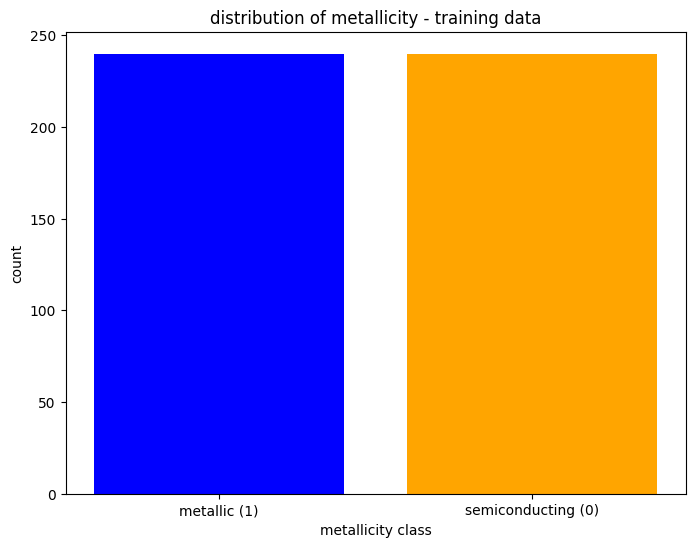

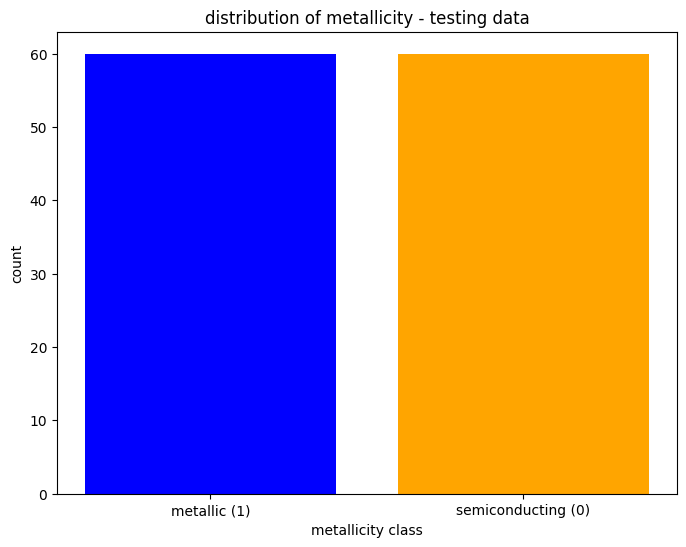

In [ ]:
# plotting data distributions
print("\n generating data distribution plots...")

# plot training data distribution
unique_train, counts_train = np.unique(y_train, return_counts=True)

plt.figure(figsize=(8, 6))
labels_train = ['metallic (1)', 'semiconducting (0)']
plt.bar(labels_train, counts_train, color=['blue', 'orange'])

plt.xlabel('metallicity class')
plt.ylabel('count')
plt.title('distribution of metallicity - training data')
plt.savefig('distribution_train.png')
print("saved 'distribution_train.png'")

# plot testing data distribution
unique_test, counts_test = np.unique(y_test, return_counts=True)

plt.figure(figsize=(8, 6))
labels_test = ['metallic (1)', 'semiconducting (0)']
plt.bar(labels_test, counts_test, color=['blue', 'orange'])

plt.xlabel('metallicity class')
plt.ylabel('count')
plt.title('distribution of metallicity - testing data')
plt.savefig('distribution_test.png')
print("saved 'distribution_test.png'")

In [ ]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test,  dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.reshape(-1,1), dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test.reshape(-1,1), dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_tensor,  y_test_tensor),  batch_size=batch_size, shuffle=False)

In [ ]:
model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=1e-3,
    max_depth=5,
    use_label_encoder=False,
    random_state=seed,
    eval_metric="logloss" # changed from eval_metrics to eval_metric
)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:52:49] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.001, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# train XGBoost
start_time = time.time()

model.fit(X_train, y_train)

train_time = time.time() - start_time

# predictions
test_start = time.time()

y_pred = model.predict(X_test)
probs = model.predict_proba(X_test)[:, 1] # changed from predict_prob to predict_proba

test_time = time.time() - test_start
total_time = train_time + test_time

In [ ]:
# calculate initial metrics (using default threshold 0.5 from model.predict)
initial_accuracy = accuracy_score(y_test, y_pred)
print(f"\ninitial test accuracy (default threshold 0.5): {initial_accuracy*100:.2f}%")

print("\nclassification report (default threshold 0.5):")
print(classification_report(y_test, y_pred, target_names=["Semi (0)", "Metal (1)"]))

# find best F1 threshold
best_f1 = 0
best_t = 0.5

for t in np.linspace(0.1, 0.9, 81):
    current_preds = (probs > t).astype(int)
    f1 = f1_score(y_test, current_preds)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print(f"\nbest threshold for F1-score: {best_t:.2f}")

# generate final predictions using the best threshold
final_preds = (probs > best_t).astype(int)

# calculate metrics with optimized threshold
optimized_accuracy = accuracy_score(y_test, final_preds)
print(f"\nfinal test accuracy (optimized threshold): {optimized_accuracy*100:.2f}%")

print("\nclassification report (optimized threshold):")
print(classification_report(y_test, final_preds, target_names=["Semi (0)", "Metal (1)"]))

# calculate confusion matrix for plotting
cm = confusion_matrix(y_test, final_preds)

# calculate ROC curve and AUC for plotting
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

# time summary
print("\ntime summary")
print(f"training time:         {train_time:.2f} seconds")
print(f"testing (prediction) time: {test_time:.2f} seconds")
print(f"total runtime (train + test): {total_time:.2f} seconds")


initial test accuracy (default threshold 0.5): 40.83%

classification report (default threshold 0.5):
              precision    recall  f1-score   support

    Semi (0)       0.42      0.50      0.46        60
   Metal (1)       0.39      0.32      0.35        60

    accuracy                           0.41       120
   macro avg       0.41      0.41      0.40       120
weighted avg       0.41      0.41      0.40       120


best threshold for F1-score: 0.46

final test accuracy (optimized threshold): 51.67%

classification report (optimized threshold):
              precision    recall  f1-score   support

    Semi (0)       1.00      0.03      0.06        60
   Metal (1)       0.51      1.00      0.67        60

    accuracy                           0.52       120
   macro avg       0.75      0.52      0.37       120
weighted avg       0.75      0.52      0.37       120


time summary
training time:         0.12 seconds
testing (prediction) time: 0.01 seconds
total runtime (train 

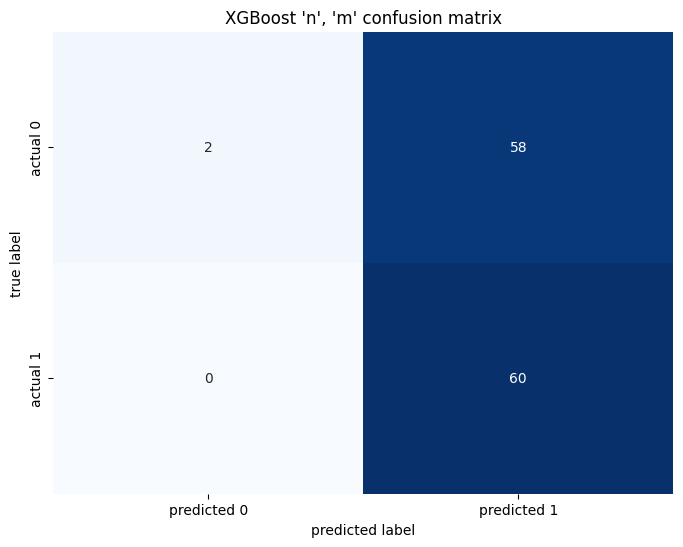

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['predicted 0', 'predicted 1'],
            yticklabels=['actual 0', 'actual 1'])

plt.title("XGBoost 'n', 'm' confusion matrix")
plt.xlabel('predicted label')
plt.ylabel('true label')
plt.savefig('xgb_n_m_conf_matrix.png')
plt.show()

/tmp/ipython-input-3503100644.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


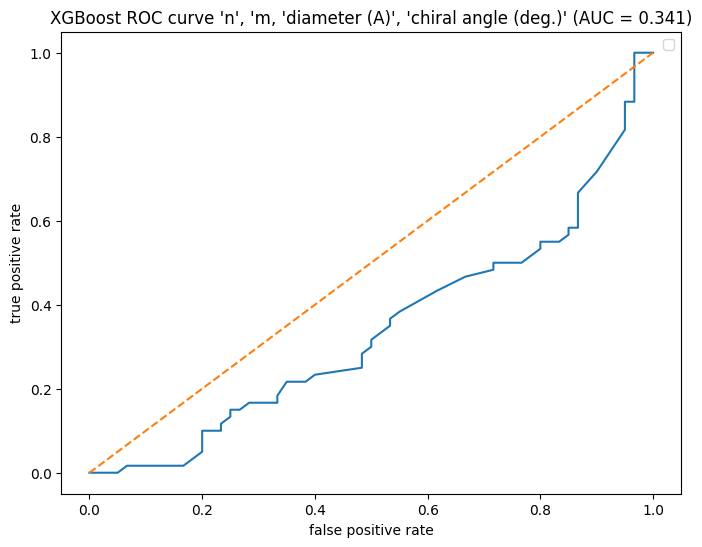

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.title(f"XGBoost ROC curve 'n', 'm, 'diameter (A)', 'chiral angle (deg.)' (AUC = {roc_auc:.3f})")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")

plt.legend()
plt.savefig('xgb_n_m_roc_curve.png')
plt.show()